In [1]:
%matplotlib inline

100.0%
100.0%
100.0%
100.0%


Epoch  1/10 | Loss: 0.6860 | Test Acc: 0.8074
Epoch  2/10 | Loss: 0.4486 | Test Acc: 0.8215
Epoch  3/10 | Loss: 0.4004 | Test Acc: 0.8462
Epoch  4/10 | Loss: 0.3711 | Test Acc: 0.8391
Epoch  5/10 | Loss: 0.3518 | Test Acc: 0.8523
Epoch  6/10 | Loss: 0.3352 | Test Acc: 0.8605
Epoch  7/10 | Loss: 0.3219 | Test Acc: 0.8615
Epoch  8/10 | Loss: 0.3106 | Test Acc: 0.8646
Epoch  9/10 | Loss: 0.3002 | Test Acc: 0.8633
Epoch 10/10 | Loss: 0.2927 | Test Acc: 0.8650


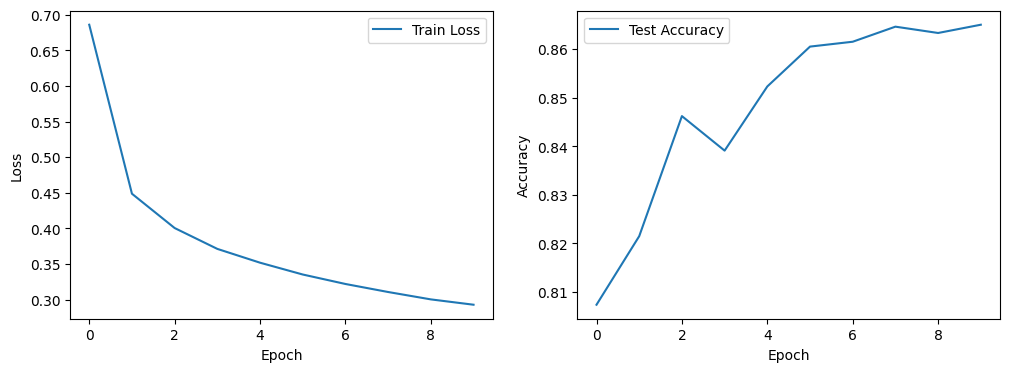

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子
torch.manual_seed(42)

# ==================== 1. 加载 Fashion-MNIST 数据集 ====================
transform = transforms.Compose([transforms.ToTensor()])

train_set = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_set = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

# ==================== 2. 手动初始化参数 ====================
input_size = 28 * 28   # 784
hidden_size = 256
output_size = 10       # 10个类别

# 正态分布初始化
W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

# 启用梯度
W1.requires_grad_(True)
b1.requires_grad_(True)
W2.requires_grad_(True)
b2.requires_grad_(True)

# ==================== 3. 实现 ReLU ====================
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

# ==================== 4. 实现 Softmax + 交叉熵损失 ====================
def softmax(logits):
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])
    return exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)

def cross_entropy_loss(probs, labels):
    # probs: [batch_size, num_classes], labels: [batch_size]
    batch_size = probs.shape[0]
    correct_log_probs = -torch.log(probs[range(batch_size), labels])
    return torch.mean(correct_log_probs)

# ==================== 5. 前向传播函数 ====================
def forward(X):
    X = X.view(X.shape[0], -1)  # 展平
    h = torch.matmul(X, W1) + b1
    h = relu(h)
    o = torch.matmul(h, W2) + b2
    return o, h

# ==================== 6. 训练循环 ====================
learning_rate = 0.1
epochs = 10

train_losses = []
test_accs = []

for epoch in range(epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        # 前向传播
        logits, _ = forward(X_batch)
        probs = softmax(logits)
        loss = cross_entropy_loss(probs, y_batch)
        
        # 反向传播（手动清空梯度）
        if W1.grad is not None:
            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()
        
        loss.backward()
        
        # 手动更新参数
        with torch.no_grad():
            W1 -= learning_rate * W1.grad
            b1 -= learning_rate * b1.grad
            W2 -= learning_rate * W2.grad
            b2 -= learning_rate * b2.grad
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # 测试准确率
    correct = 0
    total = 0
    with torch.no_grad():
        for X_test, y_test in test_loader:
            logits, _ = forward(X_test)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y_test).sum().item()
            total += y_test.size(0)
    acc = correct / total
    test_accs.append(acc)
    
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Test Acc: {acc:.4f}")

# ==================== 7. 画图 ====================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()